# Capstone Project: Toxic Comment Triage System (EDA, Baseline, Improvements, and Error Analysis)

In [30]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support
)


In [31]:
from pathlib import Path

# Resolve the training data path so the notebook can run in local or hosted environments.
candidate_paths = [
    Path("data/train.csv"),
    Path("train.csv"),
    Path("/mnt/data/train.csv")
]

for candidate in candidate_paths:
    if candidate.exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError("Could not find train.csv in data/, current folder, or /mnt/data/")

df = pd.read_csv(DATA_PATH)

print("Using data file:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Using data file: data/train.csv
Shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [32]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Dataset Inspection
The Jigsaw dataset typically contains:

- `id`
- `comment_text`
- binary toxicity labels:
  - `toxic`
  - `severe_toxic`
  - `obscene`
  - `threat`
  - `insult`
  - `identity_hate`


In [33]:
# Quick data quality checks before label mapping and modeling.
print("Missing values by column:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate comment_text rows:", df["comment_text"].duplicated().sum())

empty_comments = (df["comment_text"].astype(str).str.strip() == "").sum()
print("Empty comment_text rows:", empty_comments)

Missing values by column:


id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Duplicate rows: 0
Duplicate comment_text rows: 0
Empty comment_text rows: 0


In [34]:
# Required text and toxicity columns used to build the triage target.
toxic_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
required_cols = ["comment_text"] + toxic_cols

missing_cols = [c for c in required_cols if c not in df.columns]
print("Missing columns:", missing_cols)

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

Missing columns: []


In [35]:
def triage_label(row):
    """
    Map the original Jigsaw toxicity labels into the capstone triage labels.
    """
    # Safe: no toxic signal at all.
    if row[toxic_cols].sum() == 0:
        return "safe"

    # High-risk: severe or especially harmful categories.
    if (row["threat"] == 1) or (row["severe_toxic"] == 1) or (row["identity_hate"] == 1):
        return "high_risk"

    # Remaining toxic content is treated as ambiguous / review-worthy.
    return "needs_review"

df["triage_label"] = df.apply(triage_label, axis=1)
df["triage_label"].value_counts()

triage_label
safe            143346
needs_review     13238
high_risk         2987
Name: count, dtype: int64

In [36]:
df.head()
df = df.dropna(subset=["comment_text", "triage_label"])

In [37]:
# Summarize the triage class distribution used for downstream modeling.
triage_counts = df["triage_label"].value_counts()
triage_pct = (triage_counts / len(df) * 100).round(2)

summary_df = pd.DataFrame({
    "count": triage_counts,
    "percent": triage_pct
})

display(summary_df)

,count,percent
triage_label,,
safe,143346,89.83
needs_review,13238,8.30
high_risk,2987,1.87


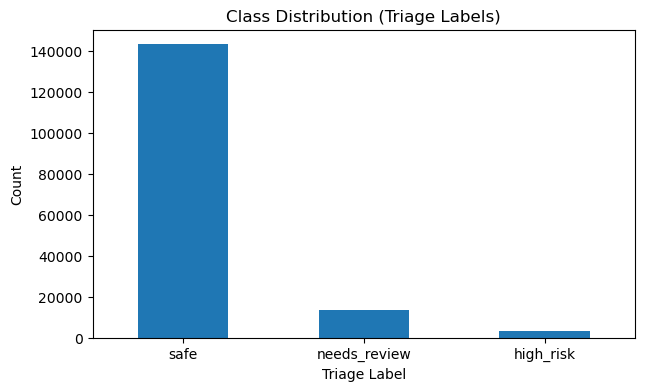

In [38]:
# Visualize class imbalance across the three triage labels.
plt.figure(figsize=(7, 4))
triage_counts.reindex(["safe", "needs_review", "high_risk"]).plot(kind="bar")
plt.title("Class Distribution (Triage Labels)")
plt.xlabel("Triage Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Key EDA Insights
- The dataset is imbalanced, with `safe` as the majority class.
- This matters because a model may over-predict the majority class.
- For this reason, **macro F1-score** will be used for baseline evaluation.
- The dataset is multi-label, meaning a single comment can have multiple toxicity labels simultaneously. This reflects different types and levels of toxic behavior rather than a single binary classification.


In [39]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    
    # Replace URLs and emails (optional but useful)
    text = re.sub(r"http\S+|www\S+", " URL ", text)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    
    # Replace line breaks / tabs
    text = re.sub(r"[\r\n\t]+", " ", text)
    
    # Normalize spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["comment_text_clean"] = df["comment_text"].astype(str).apply(clean_text)
df[["comment_text", "comment_text_clean"]].head(3)


,comment_text,comment_text_clean
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d'aww! he matches this background colour i'm s...
2,"Hey man, I'm really not trying to edit war. It...","hey man, i'm really not trying to edit war. it..."


In [40]:
# Keep text-length features minimal for EDA; they are not used in the final model.
df["char_count"] = df["comment_text"].astype(str).apply(len)
df["word_count"] = df["comment_text"].astype(str).apply(lambda x: len(str(x).split()))

feature_cols = ["char_count", "word_count"]
df[feature_cols].head()

,char_count,word_count
0,264,43
1,112,17
2,233,42
3,622,113
4,67,13


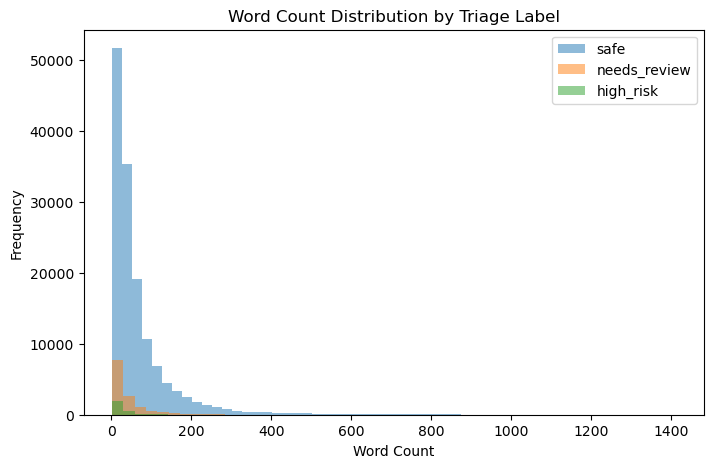

In [41]:
# Create a figure with specified dimensions (width=8, height=5 inches)
# This provides enough space for a clear visualization with multiple histograms
plt.figure(figsize=(8,5))

# Loop through each triage category to create overlapping histograms
for label in ["safe", "needs_review", "high_risk"]:
    # Create a subset of data containing only word counts for the current triage label
    # df.loc[] is used for conditional row selection based on the triage_label column
    subset = df.loc[df["triage_label"] == label, "word_count"]
    
    # Plot a histogram for this subset with:
    # - 50 bins to show detailed distribution
    # - alpha=0.5 for transparency so overlapping histograms are visible
    # - label parameter to identify this category in the legend
    plt.hist(subset, bins=50, alpha=0.5, label=label)

# Add a descriptive title to the plot
plt.title("Word Count Distribution by Triage Label")

# Label the x-axis to indicate what is being measured
plt.xlabel("Word Count")

# Label the y-axis to indicate the frequency scale
plt.ylabel("Frequency")

# Add a legend to distinguish between the different triage categories
# The legend will use the labels specified in the plt.hist() calls
plt.legend()

# Display the completed visualization
plt.show()

Text length does not show a strong correlation with toxicity across classes, indicating that simple length-based features are insufficient and that semantic patterns in the text are more important for classification.

In [42]:
def get_top_ngrams(texts, ngram_range=(1,1), top_n=5, min_df=5, stop_words="english"):
    """
    Return the most frequent n-grams for a slice of text.
    """
    texts = pd.Series(texts).dropna().astype(str)

    if len(texts) == 0:
        return pd.DataFrame(columns=["term", "count"])

    vec = CountVectorizer(
        stop_words=stop_words,
        ngram_range=ngram_range,
        min_df=min_df
    )

    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    top_idx = freqs.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "term": terms[top_idx],
        "count": freqs[top_idx]
    })

In [43]:
# Compare the most common unigrams across triage classes.
for label in ["safe", "needs_review", "high_risk"]:
    print(f"\nTop unigrams for: {label}")
    display(
        get_top_ngrams(
            df.loc[df["triage_label"] == label, "comment_text_clean"],
            ngram_range=(1,1),
            top_n=5,
            min_df=5
        )
    )


Top unigrams for: safe


,term,count
0,article,55930
1,page,44000
2,wikipedia,42330
3,talk,35371
4,just,25082



Top unigrams for: needs_review


,term,count
0,like,3086
1,wikipedia,2815
2,just,2411
3,fuck,2404
4,don,2366



Top unigrams for: high_risk


,term,count
0,fuck,7593
1,nigger,2975
2,suck,2584
3,ass,2243
4,shit,2072


In [44]:
# Compare the most common bigrams across triage classes.
for label in ["safe", "needs_review", "high_risk"]:
    print(f"\nTop bigrams for: {label}")
    display(
        get_top_ngrams(
            df.loc[df["triage_label"] == label, "comment_text_clean"],
            ngram_range=(2,2),
            top_n=5,
            min_df=3
        )
    )


Top bigrams for: safe


,term,count
0,talk page,12693
1,speedy deletion,4389
2,fair use,3143
3,don know,2580
4,feel free,2309



Top bigrams for: needs_review


,term,count
0,hate hate,1570
1,moron hi,1298
2,hi moron,1298
3,wanker wanker,963
4,bullshit bullshit,833



Top bigrams for: high_risk


,term,count
0,fuck fuck,2821
1,nigger nigger,2035
2,ass ass,1127
3,suck suck,1126
4,faggot faggot,715


The presence of common toxic phrases in the data suggests that toxicity is often expressed through word combinations rather than individual words. This motivates the use of TF-IDF with n-gram features to capture contextual patterns.

## EDA Findings
1. The dataset is highly imbalanced, with most comments being non-toxic. This makes accuracy unreliable and motivates the use of macro F1 for evaluation.

2. Comments can have multiple toxicity labels, indicating that toxicity exists on a spectrum rather than being binary. This supports the use of a triage-based classification system.

3.Some comments fall into ambiguous categories where toxicity is not clearly defined, reinforcing the need for a “needs human review” class.

4. Text length does not strongly correlate with toxicity, indicating that simple features are insufficient and semantic understanding is required.

5. N-gram patterns show that toxicity is often expressed through phrases rather than individual words, motivating the use of TF-IDF with n-gram features.


## How EDA Influenced Modeling Decisions
The EDA revealed several important characteristics of the dataset that influenced modeling decisions. The class imbalance led to the use of macro F1 instead of accuracy. The presence of multiple toxicity labels and varying severity levels motivated the design of a three-class triage system instead of binary classification. The lack of strong correlation between text length and toxicity indicated that semantic features are more important than simple heuristics. Finally, the presence of phrase-level toxicity patterns supported the use of TF-IDF with n-grams for feature representation.


## System Design
The system takes user-generated text as input, applies preprocessing and feature extraction using TF-IDF, and uses a Logistic Regression model to predict class probabilities. A threshold-based decision layer is then applied to prioritize high-risk detection and route ambiguous cases for human review, enabling a risk-aware and scalable decision-making workflow.
Threshold tuning converts model probabilities into risk-aware decisions rather than relying solely on maximum probability.

## Baseline Model Setup

In [45]:
# Clean the modeling dataset and define inputs/targets for the triage task.
df = df.dropna(subset=["comment_text", "triage_label"])
df["comment_text_clean"] = df["comment_text"].astype(str).apply(clean_text)

X = df["comment_text_clean"]
y = df["triage_label"]

from sklearn.model_selection import train_test_split

# Stratified split preserves the class imbalance pattern in train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF converts text into weighted numeric features; bigrams help capture phrase-level toxicity.
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [47]:
from sklearn.linear_model import LogisticRegression

# Baseline classifier: simple, fast, and interpretable for sparse text features.
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [48]:
# Predict class labels and class probabilities for baseline evaluation.
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)

In [49]:
from sklearn.metrics import classification_report, confusion_matrix

labels = ["safe", "needs_review", "high_risk"]
class_names = ["Safe", "Needs Human Review", "High Risk"]

print(classification_report(y_test, y_pred, labels=labels, target_names=class_names))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred, labels=labels)
print(cm)

                    precision    recall  f1-score   support

              Safe       0.96      0.99      0.98     28670
Needs Human Review       0.75      0.52      0.62      2648
         High Risk       0.64      0.30      0.41       597

          accuracy                           0.94     31915
         macro avg       0.78      0.61      0.67     31915
      weighted avg       0.93      0.94      0.93     31915


Confusion Matrix:

[[28501   163     6]
 [ 1166  1386    96]
 [  110   305   182]]


## Baseline Model Performance Analysis
The baseline model achieves high overall accuracy (94%), but this is largely driven by strong performance on the majority ‘safe’ class. The macro F1-score of 0.67 reveals weaker performance across minority classes.

 The model performs well on safe content (F1 = 0.98), but struggles with ‘needs human review’ (F1 = 0.62) and especially ‘high-risk’ content (F1 = 0.41). The recall for high-risk is particularly low (30%), meaning that a large portion of harmful content is not detected.

 Confusion matrix analysis shows that some high-risk comments are incorrectly classified as safe, which is a critical issue in real-world applications. This indicates that the model is biased toward the majority class and highlights the need for improvements to better handle class imbalance and improve detection of high-risk content.

## Improvement 1: Class Weighting

In [50]:
from sklearn.linear_model import LogisticRegression

# Class weighting shifts more attention to minority classes, especially high-risk content.
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [51]:
# Re-evaluate after class weighting to measure the recall/precision trade-off.
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)

In [52]:
from sklearn.metrics import classification_report, confusion_matrix

labels = ["safe", "needs_review", "high_risk"]
class_names = ["Safe", "Needs Human Review", "High Risk"]

print(classification_report(y_test, y_pred, labels=labels, target_names=class_names))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred, labels=labels)
print(cm)

                    precision    recall  f1-score   support

              Safe       0.98      0.93      0.96     28670
Needs Human Review       0.47      0.68      0.56      2648
         High Risk       0.38      0.62      0.47       597

          accuracy                           0.90     31915
         macro avg       0.61      0.74      0.66     31915
      weighted avg       0.93      0.90      0.91     31915


Confusion Matrix:

[[26678  1810   182]
 [  442  1788   418]
 [   30   196   371]]


After applying class weighting, the model shows a significant improvement in recall for the high-risk class, increasing from 0.30 to 0.62. This indicates that the model is now more effective at identifying harmful content.

However, this improvement comes with a trade-off in precision and overall accuracy, as more comments are incorrectly flagged as high-risk or needs review. This trade-off is acceptable in this use case, as missing harmful content is more critical than over-flagging safe content.

Overall, class weighting helps shift the model from being biased toward the majority class to a more balanced and risk-aware classifier.

## Improvement 2: Threshold Tuning

In [53]:
# Inspect the probability outputs before applying custom decision thresholds.
proba_df = pd.DataFrame(
    y_proba,
    columns=model.classes_
)

proba_df.head()
print(model.classes_)

['high_risk' 'needs_review' 'safe']


In [54]:
import numpy as np
import pandas as pd

proba_df = pd.DataFrame(y_proba, columns=model.classes_)

# Custom thresholds make the final system more risk-aware than simple max-probability prediction.
high_risk_threshold = 0.30
review_threshold = 0.40

def apply_thresholds(row):
    if row.get("high_risk", 0) >= high_risk_threshold:
        return "high_risk"
    elif row.get("needs_review", 0) >= review_threshold:
        return "needs_review"
    else:
        return "safe"

y_pred_threshold = proba_df.apply(apply_thresholds, axis=1)

In [55]:
from sklearn.metrics import classification_report, confusion_matrix

labels = ["safe", "needs_review", "high_risk"]
class_names = ["Safe", "Needs Human Review", "High Risk"]

print(classification_report(
    y_test,
    y_pred_threshold,
    labels=labels,
    target_names=class_names
))

cm_threshold = confusion_matrix(y_test, y_pred_threshold, labels=labels)
print("\nConfusion Matrix:\n")
print(cm_threshold)

                    precision    recall  f1-score   support

              Safe       0.99      0.90      0.94     28670
Needs Human Review       0.38      0.61      0.47      2648
         High Risk       0.31      0.74      0.44       597

          accuracy                           0.88     31915
         macro avg       0.56      0.75      0.62     31915
      weighted avg       0.92      0.88      0.89     31915


Confusion Matrix:

[[25899  2455   316]
 [  368  1617   663]
 [   23   135   439]]


Threshold tuning further improved the model’s ability to detect high-risk content by increasing recall from 0.62 to 0.74. This significantly reduces the number of harmful comments incorrectly classified as safe.

However, this comes at the cost of lower precision and overall accuracy, as more comments are flagged as high-risk or needs review. This trade-off is acceptable in this use case, where missing harmful content is more critical than over-flagging.

The threshold-based decision logic also aligns better with a real-world moderation workflow, where high-risk content is prioritized and ambiguous cases are routed for human review.

## Model Comparison
Three versions of the model were evaluated:

- Baseline model (TF-IDF + Logistic Regression)
- Class-weighted model
- Threshold-tuned model

The baseline model achieved high overall accuracy but performed poorly on the high-risk class. Class weighting significantly improved recall for high-risk content, while threshold tuning further improved detection of harmful content at the cost of precision.

This progression demonstrates how the model was iteratively improved to align with the risk-sensitive nature of the problem.

| Model           | Accuracy | Macro F1 | High-Risk Recall |
| --------------- | -------- | -------- | ---------------- |
| Baseline        | ~0.94    | ~0.67    | 0.30             |
| Class Weighted  | ~0.90    | ~0.66    | 0.62             |
| Threshold Tuned | ~0.88    | ~0.62    | 0.74             |


## Error Analysis

In [56]:
# Review misclassified examples to understand model failure patterns.
results_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "actual": y_test.reset_index(drop=True),
    "predicted": pd.Series(y_pred_threshold).reset_index(drop=True)
})

errors = results_df[results_df["actual"] != results_df["predicted"]]
errors.sample(10)

,text,actual,predicted
23679,my name is not jason. you are one paranoid per...,needs_review,safe
2567,how you can get away with such shenanigans is ...,safe,needs_review
25356,bad motherfuckers there are a lot of them out ...,needs_review,safe
4047,"it's raining, and i don't have an umbrella, wi...",safe,needs_review
14530,""" i really don't know, because the gnu license...",needs_review,safe
25832,is that what you want? for me to go away from ...,safe,needs_review
20924,"haha i'm not really one to genrewank, but wint...",safe,needs_review
3886,truth truth you quit wikipedia because i force...,safe,needs_review
17593,id say that animal farm is more of an attack a...,safe,needs_review
23376,this article is useless without pics,safe,needs_review


Error analysis reveals several patterns in model misclassifications. The model tends to over-rely on keyword-based signals, which leads to safe comments containing strong or sensitive terms being incorrectly classified as high-risk or needs review.

Additionally, the model struggles with contextual understanding, particularly in cases where toxic terms are used in a non-abusive or discussion-based context. This results in false positives for high-risk classification.

The model also shows difficulty distinguishing between ‘needs review’ and ‘high-risk’ categories, especially for borderline cases involving strong but not clearly harmful language.

Finally, the model has limited ability to interpret tone, such as sarcasm or argumentative language, which leads to misclassification of non-toxic but confrontational comments.

These limitations highlight the constraints of TF-IDF-based models and reinforce the importance of human-in-the-loop review for ambiguous cases.

More advanced models such as transformer-based architectures could better capture contextual meaning and improve performance on ambiguous or sarcastic text.

## Synthetic Edge Case Testing

In [57]:
# Controlled edge cases complement dataset-based evaluation by stress-testing ambiguity and sarcasm.
test_cases = [
    "Hello, how are you?",                         # safe
    "You are such an idiot",                       # clear insult
    "Oh great, another brilliant idea",            # sarcasm
    "That’s not very smart of you",                # ambiguous / borderline
    "I disagree with your opinion",                # safe but argumentative
    "Go to hell you moron",                        # strong insult
    "Nice job genius 🙄",                          # sarcasm
]

In [58]:
test_clean = [clean_text(t) for t in test_cases]
test_tfidf = vectorizer.transform(test_clean)
test_proba = model.predict_proba(test_tfidf)

proba_df = pd.DataFrame(test_proba, columns=model.classes_)
test_pred = proba_df.apply(apply_thresholds, axis=1)

pd.DataFrame({
    "text": test_cases,
    "prediction": test_pred
})

,text,prediction
0,"Hello, how are you?",safe
1,You are such an idiot,needs_review
2,"Oh great, another brilliant idea",safe
3,That’s not very smart of you,needs_review
4,I disagree with your opinion,safe
5,Go to hell you moron,needs_review
6,Nice job genius 🙄,safe


The model was evaluated on a set of synthetic edge cases designed to test ambiguity, sarcasm, and borderline toxicity.

Results show that the model performs well on clearly safe inputs and reasonably routes borderline toxic language to the “needs review” category, which aligns with the intended triage behavior.

However, the model struggles with sarcastic statements such as “Oh great, another brilliant idea” and “Nice job genius 🙄”, incorrectly classifying them as safe. This occurs because the TF-IDF representation relies on word-level features and cannot capture tone or contextual meaning.

These results reinforce findings from error analysis, highlighting that while the model is effective for explicit toxicity detection, it has limitations in handling nuanced language and requires human review for such cases.

## Limitations
The main limitations of the system stem from its reliance on TF-IDF features and a linear classification model. The model lacks contextual understanding and struggles with sarcasm, tone, and cases where toxic words are used in non-abusive contexts. It also faces challenges with class imbalance, where minority classes like high-risk are harder to predict accurately. Additionally, the model depends heavily on keyword-based signals, which can lead to false positives for strong language and false negatives for subtle toxicity. These limitations highlight the need for human-in-the-loop review and more advanced contextual models.

## Future Improvements
If more time were available, this system could be improved in several ways. First, expanding or rebalancing the dataset would help improve detection of minority classes, especially high-risk content. Second, transformer-based models such as BERT or RoBERTa could be explored to better capture contextual meaning, sarcasm, and tone. Third, the evaluation process could be extended with more controlled edge cases and a reviewer-feedback loop to better reflect real-world moderation settings.

## Final Model Summary
The final system uses TF-IDF features with a Logistic Regression model, enhanced with class weighting and threshold tuning. 

Class weighting improved recall for minority classes, especially high-risk content, while threshold tuning further increased detection of harmful content by prioritizing recall over precision. 

Although these improvements reduced overall accuracy and precision, the system became more effective at identifying high-risk and ambiguous cases. This trade-off is acceptable for the use case, where missing harmful content is more critical than over-flagging safe content.

## Conclusion
This project demonstrates how a machine learning system can be used to support human decision-making through a triage-based classification approach. 

Rather than focusing solely on model accuracy, the system was designed to prioritize risk-aware decisions by routing content into safe, needs review, and high-risk categories. Through iterative improvements, including class weighting and threshold tuning, the model was made more effective at detecting harmful content.

The combination of automated classification and human-in-the-loop review provides a practical and scalable approach for real-world moderation systems, balancing efficiency with safety.